# Регрессия для IC50

Необходимо сравнить различные модели с настройкой гиперпараметров для предсказания значения ингибирующей концентрации соединений(IC50) на основе их молекулярных дескрипторов. IC50 является количественной целевой переменной, характеризующей эффективность потенциальных лекарственных соединений.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

import xgboost as xgb
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

## Загрузка данных

In [ ]:
df = pd.read_csv('/data/clean_data.csv')
print('Размерность датасета:', df.shape)

Размерность датасета: (969, 213)


In [ ]:
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,...,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.0,969.000000,969.000000,969.000000
mean,220.726223,586.419908,73.967907,10.893712,10.893712,0.179533,-0.960140,0.577633,29.370350,351.486139,...,0.055728,0.012384,0.009288,0.001032,0.001032,0.053664,0.0,0.070175,0.208462,0.007224
std,397.172441,633.624464,695.564665,3.284005,3.284005,0.168928,1.567568,0.213316,12.605779,127.388186,...,0.263069,0.110649,0.095975,0.032125,0.032125,0.225469,0.0,0.255574,1.231428,0.084730
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999345,1.488095,10.006389,10.006389,0.050979,-1.333174,0.442842,18.500000,266.252000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,45.338355,424.166213,3.900000,12.196496,12.196496,0.123850,-0.419485,0.634372,29.200000,318.373000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,231.373089,891.776925,16.375000,13.178870,13.178870,0.291020,0.007873,0.742483,38.600000,413.670000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


## Подготовка данных к обучению модели

При моделировании необходимо учитывать, что индекс селективности SI вычисляется на основе значений IC50 и CC50. Следовательно, для задач прогнозирования SI нельзя использовать IC50 и CC50 в качестве признаков. Аналогично, при моделировании IC50 запрещено использовать SI и CC50, а при моделировании CC50 — SI и IC50, чтобы избежать утечки данных и некорректного завышения качества моделей.

Для решения задач регрессии с целевыми переменными, характеризующимися сильной асимметрией распределения, выявленной при анализе данных, применяется логарифмическое преобразование log1p. Расчет метрик качества при этом выполняется в логарифмической шкале, что позволяет корректно оценивать относительные ошибки предсказаний.

Построим графики распределния целевой переменной IC50 и ее логарифма log1p(IC50).

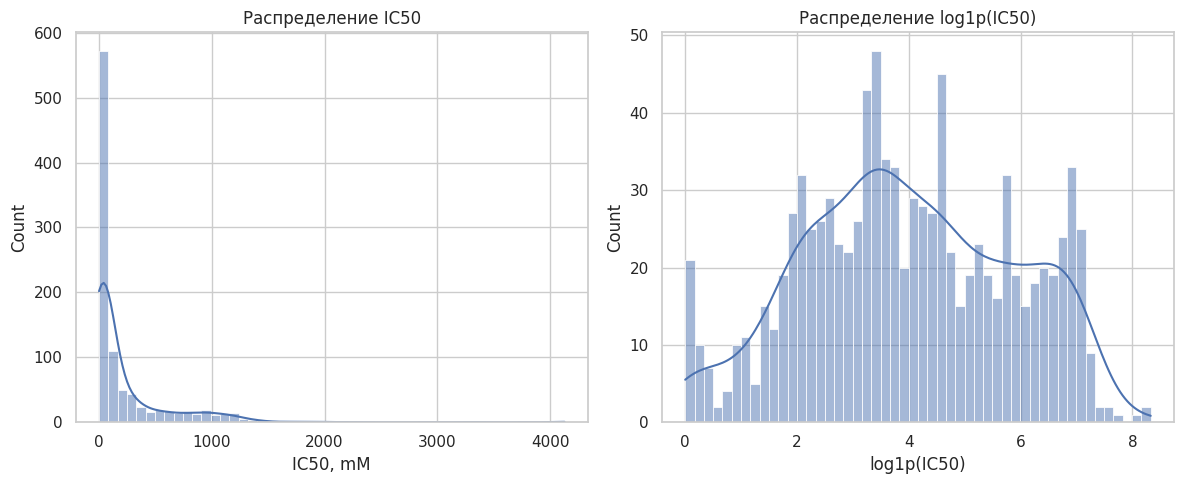

In [ ]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Исходное распределение IC50
sns.histplot(df['IC50, mM'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Распределение IC50')
axes[0].set_xlabel('IC50, mM')

# Логарифмическое распределение IC50
sns.histplot(np.log1p(df['IC50, mM']), kde=True, bins=50, ax=axes[1])
axes[1].set_title('Распределение log1p(IC50)')
axes[1].set_xlabel('log1p(IC50)')

plt.tight_layout()
plt.show()

In [ ]:
# Удаляем утечки, так как SI = CC50/IC50
df = df.drop(columns=['SI', 'CC50, mM'])

# Признаки / таргет
X = df.drop(columns=['IC50, mM'])
y =  np.log1p(df['IC50, mM'])

Так как ранее на этапе EDA в общей даграмме присутствовало много признаком, которые сильно коррелируют между собой, напишем функцию для устранения мультиколлинеарности путем удаления этих сильно коррелирующих между собой переменных.

In [ ]:
def drop_high_corr(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

X, dropped_cols = drop_high_corr(X, threshold=0.8)

print(f"Удалено {len(dropped_cols)} признаков")

Удалено 72 признаков


Данная функция вычисляет матрицу абсолютных коэффициентов корреляции Пирсона для всех признаков, выделяет верхнюю треугольную часть матрицы, исключая главную диагональ и идентифицирует пары признаков, коэффициент корреляции между которыми превышает заданный порог. Для каждой такой пары функция помечает один из признаков для удаления, оставляя в датасете только некоррелирующие между собой переменные.

Это важно для многих моделей машинного обучения, особенно линейных, где высокая корреляция между признаками приводит к нестабильности оценок коэффициентов, снижению интерпретируемости и переобучению.

Дополнительно проведем количественную оценку мультиколлинеарности в наборе признаков с использованием фактора инфляции дисперсии.

In [ ]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["features"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False)

vif_result = calculate_vif(X)
vif_result

high_vif_features = vif_result[vif_result['VIF'] > 40]['features'].tolist()
X_clean = X.drop(columns=high_vif_features)
X_clean

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.094096,0.387225,0.387225,0.417362,42.928571,0,0.038844,-0.293526,0.642857,14.822266,...,0,0,0,0,0,0,0,0,3,0
1,3.961417,0.533868,0.533868,0.462473,45.214286,0,0.012887,-0.313407,0.607143,14.975110,...,0,0,0,0,0,0,0,0,3,0
2,2.627117,0.543231,0.543231,0.260923,42.187500,0,0.094802,-0.325573,0.562500,15.353938,...,0,0,0,0,0,0,0,0,3,0
3,5.097360,0.390603,0.390603,0.377846,41.862069,0,0.038844,-0.293526,0.620690,14.821216,...,0,0,0,0,0,0,0,0,4,0
4,5.150510,0.270476,0.270476,0.429038,36.514286,0,0.062897,-0.257239,0.600000,14.831112,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964,12.934891,0.048029,-0.476142,0.382752,49.133333,0,0.317890,-0.468587,1.133333,16.586886,...,0,0,0,0,0,0,0,0,0,0
965,13.635345,0.030329,-0.699355,0.369425,44.542857,0,0.327562,-0.467493,1.085714,16.586914,...,0,0,0,0,0,0,0,0,0,0
966,13.991690,0.026535,-0.650790,0.284923,41.973684,0,0.327887,-0.467485,1.157895,32.166365,...,1,0,0,0,0,0,0,0,0,0
967,13.830180,0.146522,-1.408652,0.381559,39.000000,0,0.312509,-0.468755,0.756757,16.540061,...,0,0,0,0,0,0,0,0,0,0


Эта функция вычисляет каждого признака VIF, который показывает, насколько сильно дисперсия оцененного коэффициента регрессии увеличивается из-за корреляции этого признака с другими признаками. Значение VIF вычисляется как отношение дисперсии модели со всеми признаками к дисперсии модели, где данный признак регрессируется на все остальные.

Чем выше значение VIF, тем сильнее мультиколлинеарность: для нашей задачи будем использовать пороговое значение 40.

Таким образом, с использованием двух методов мы избавимся от мультиколлинеарности.



Разделим данные на тренировочную и тестовую выбоки:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 775 строк
Тестовая выборка: 194 строк


## Обучение моделей

Для данной задачи будем рассматривать 6 различных моделей: гребневая регрессия, регрессия Лассо, случайный лес, градиентный бустинг, XGBoost и LightGBM.

Для каждой модели проводится подбор гиперпараметров с помощью GridSearchCV и 5-кратной кросс-валидации, в качестве метрики оптимизации выбрана среднеквадратичная ошибка (MSE).

Оценивать качество моделей будем по трем метрикам:
- средняя абсолютная ошибка - MAE
- корень из среднеквадратичной ошибки - RMSE
- коэффициент детерминации - R^2

In [ ]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "R2_test": r2_score(y_test, pred_test)
    }

Выше представлена общая функция для предсказания и оценки модели. Она обучает модель на тренировочных данных, делает предсказания на обеих выборках и возвращает ключевые метрики: MAE (на обучении и тесте), RMSE и R^2 на тестовых данных.

Перейдем к обучению моделей:

**Гребневая регрессия**

In [ ]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

params_ridge = {
    'model__alpha': [0.1, 1, 10, 50, 100, 150, 200]
}

grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)

res_ridge = evaluate(grid_ridge.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_ridge.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_ridge.best_score_:.4f}")

Лучшие параметры: {'model__alpha': 200}
Наилучшая метрика MSE: 2.9065


**Регрессия Лассо**

In [ ]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=10000))
])

params_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 15]
}

grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

res_lasso = evaluate(grid_lasso.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_lasso.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_lasso.best_score_:.4f}")

Лучшие параметры: {'model__alpha': 0.1}
Наилучшая метрика MSE: 2.8363


**Случайный лес**

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

params_rf = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 5, 7, -1],
    'min_samples_split': [2, 4, 8],
}

grid_rf = GridSearchCV(rf, params_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

res_rf = evaluate(grid_rf.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_rf.best_score_:.4f}")

Лучшие параметры: {'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 600}
Наилучшая метрика MSE: 2.2433


**Градиентный бустинг**

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

params_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.85, 1.0],
}

grid_gb = GridSearchCV(gb, params_gb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)

res_gb = evaluate(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_gb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7}
Наилучшая метрика MSE: 2.2262


**XGBRegressor**

In [ ]:
xgbr = xgb.XGBRegressor(random_state=42, n_jobs=-1)

params_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.02, 0.05, 0.1]
}

grid_xgb = GridSearchCV(xgbr, params_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

res_xgb = evaluate(grid_xgb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_xgb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 200}
Наилучшая метрика MSE: 2.2624


**LightGBM**

In [ ]:
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

params_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
}

grid_lgbm = GridSearchCV(lgbm, params_lgbm, cv=5, scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=1)
grid_lgbm.fit(X_train, y_train)

res_lgbm = evaluate(grid_lgbm.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_lgbm.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_lgbm.best_score_:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000968 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5360
[LightGBM] [Info] Number of data points in the train set: 775, number of used features: 61
[LightGBM] [Info] Start training from score 3.975062
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

Соберем датафрейм с результатами моделей:

In [ ]:
results = pd.DataFrame({
    'Ridge': res_ridge,
    'Lasso': res_lasso,
    'RandomForest': res_rf,
    'GradientBoosting': res_gb,
    'XGBoost': res_xgb,
    'LGBMRegressor': res_lgbm
}).T

results.sort_values('RMSE_test')

,MAE_train,MAE_test,RMSE_test,R2_test
RandomForest,0.795916,1.080104,1.334494,0.517329
GradientBoosting,0.761460,1.089058,1.348086,0.507447
XGBoost,0.842383,1.105841,1.362694,0.496715
LGBMRegressor,0.595769,1.106040,1.402725,0.466711
Ridge,1.218355,1.275306,1.531045,0.364678
Lasso,1.334679,1.390099,1.666605,0.247194


В результате построения 6 моделей  можно сделать следующие выводы:

- Наилучшие показатели демонстрирует Random Forest, который достигает самой низкой ошибки на тестовой выборке (RMSE = 1.334, MAE = 1.080) и самого высокого коэффициента детерминации (0.517). Это означает, что модель объясняет примерно 51.7% дисперсии целевой переменной, а средняя ошибка предсказания составляет около 1.08 единиц IC50.

- Gradient Boosting показывает близкие результаты (R^2 = 0.507, RMSE = 1.348), что характерно для древовидных ансамблей - они хорошо справляются с нелинейными зависимостями и взаимодействиями признаков, не требуя масштабирования данных.

- XGBoost и LightGBM показали более высокую ошибку обобщения, хотя во многих задачах градиентный бустинг на деревьях часто превосходит случайный лес. Это может быть связано с переобучение LightGBM, так как она имеет наилучший MAE на обучении, но наибольший разрыв с тестом.  Возможна неоптимальная настройка гиперпараметров, ведь для XGBoost и LGBM требуется более тщательный подбор, тогда как Random Forest менее чувствителен к параметрам. Дополнительно на качество мог повлиять малый размер выборки и сохранение "выбросов".

- Линейные модели ожидаемо показывают худшие результаты . Это говорит о том, что зависимость IC50 от дескрипторов является нелинейной, и линейные аппроксимации недостаточно хорошо описывают данные. L

Рекомендация:
Для практического использования стоит выбрать Random Forest как наиболее сбалансированную модель с наилучшим R^2 и минимальной ошибкой на тесте. Для дальнейшего улучшения можно провести более глубокий подбор гиперпараметров для XGBoost/LGBM, добавить дополнительные признаки или рассмотреть нелинейные методы.


